In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df=pd.read_csv('Student_Performance.csv')

In [79]:
df.head(8)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
5,3,78,No,9,6,61.0
6,7,73,Yes,5,6,63.0
7,8,45,Yes,4,6,42.0


In [80]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [81]:
#let us convert the categorical variable into int
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [82]:
cat_map={'Yes':1,'No':0}
df['Exe_encoded']=df['Extracurricular Activities'].map(cat_map)


In [83]:
df.head(5)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Exe_encoded
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,0
2,8,51,Yes,7,2,45.0,1
3,5,52,Yes,5,2,36.0,1
4,7,75,No,8,5,66.0,0


In [84]:
df_copy=df.copy()

In [85]:
df_copy.drop('Extracurricular Activities',inplace=True,axis=1)

In [86]:
df_copy.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Exe_encoded
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730,0.003873
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189,0.008369
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106,-0.023284
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268,0.013103
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000,0.024525
Exe_encoded,0.003873,0.008369,-0.023284,0.013103,0.024525,1.000000


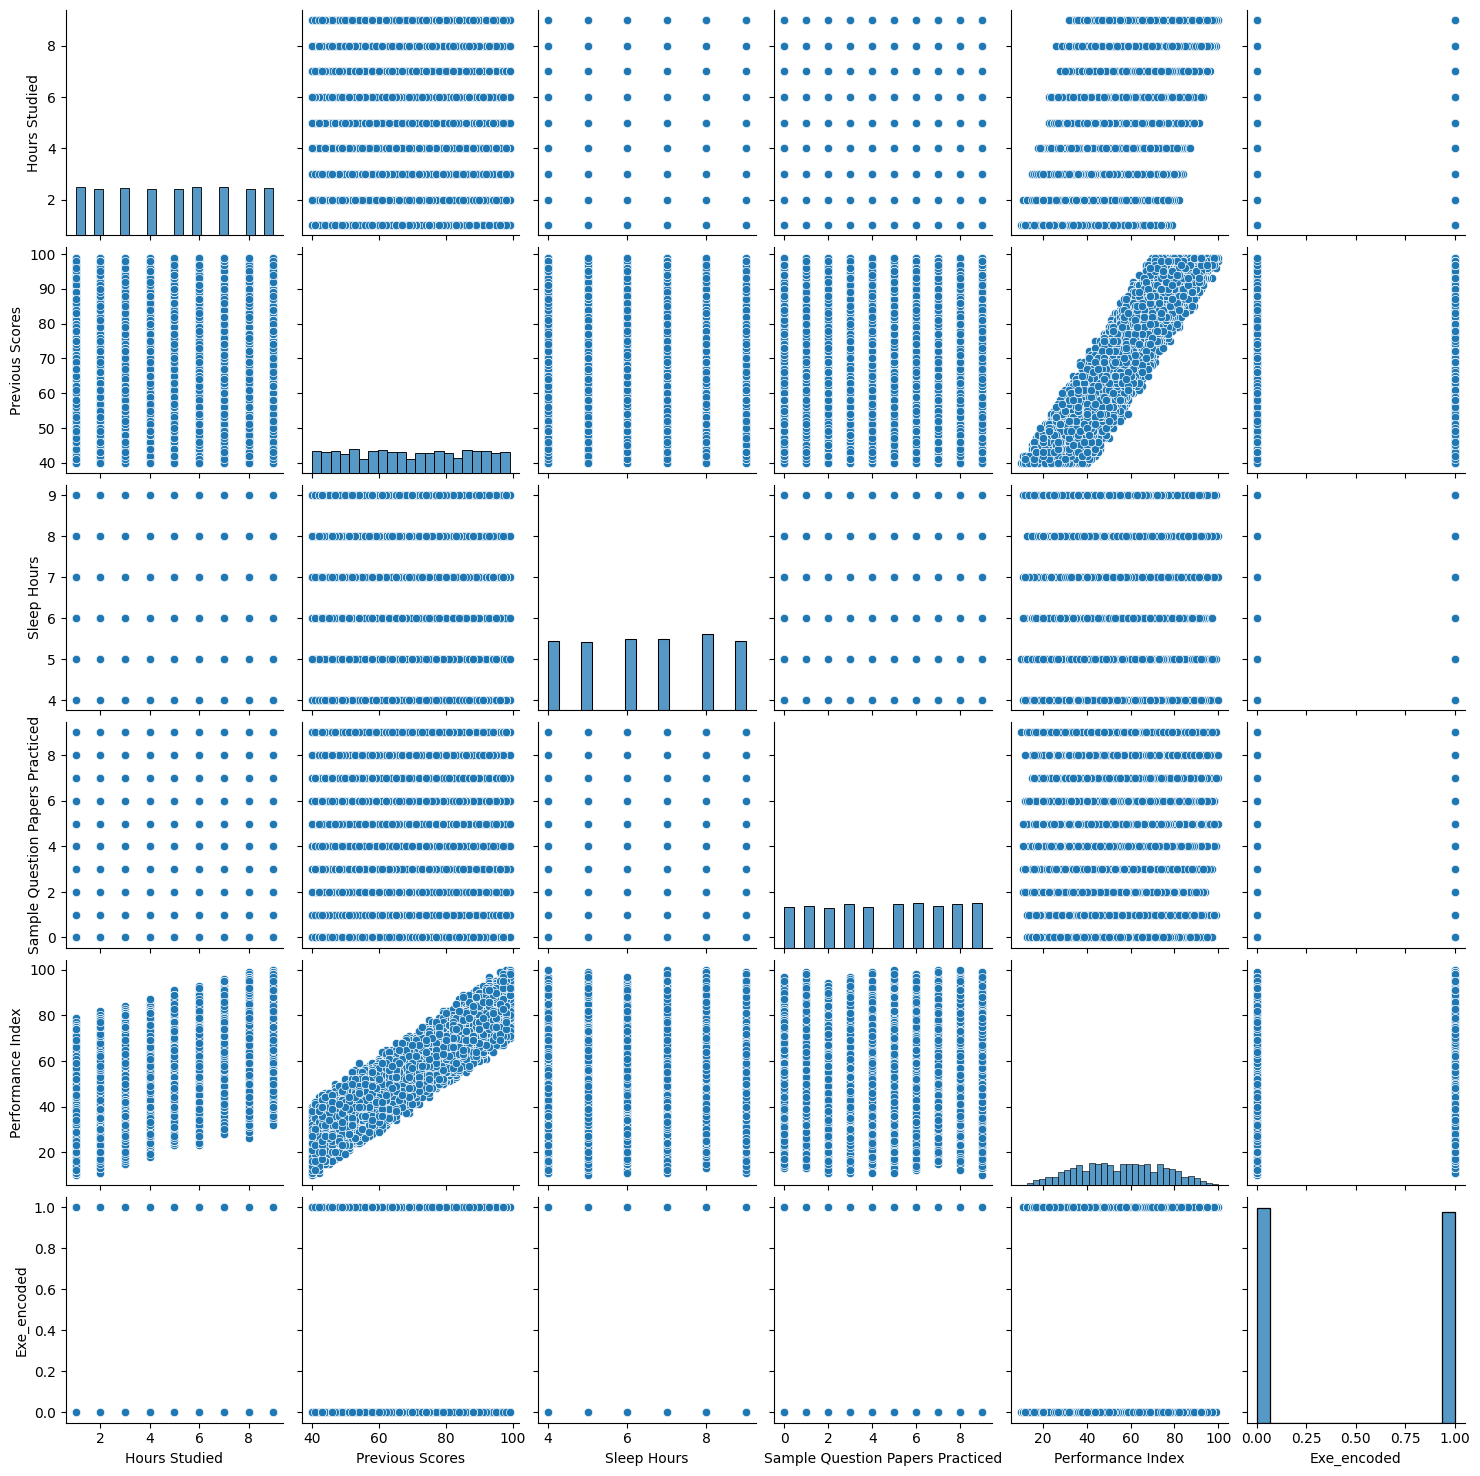

In [87]:
sns.pairplot(df_copy)

In [88]:
df_copy[['Exe_encoded','Performance Index']] = \
df_copy[['Performance Index','Exe_encoded']].values


In [103]:
df_copy.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Exe_encoded
0,7,99,9,1,1.0,91.0
1,4,82,4,2,0.0,65.0
2,8,51,7,2,1.0,45.0
3,5,52,5,2,1.0,36.0
4,7,75,8,5,0.0,66.0


In [90]:
X=df_copy.iloc[:,:-1]
y=df_copy.iloc[:,-1]

In [91]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [92]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [93]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [94]:
X_train

array([[ 0.00796272, -1.19062085, -0.90874945,  0.13314392, -0.98912579],
       [ 0.77854894,  1.05902612, -1.49731775,  1.53122497,  1.01099376],
       [-0.76262349,  1.40512565,  0.26838714, -1.26493713,  1.01099376],
       ...,
       [ 1.54913515, -1.24830411,  0.26838714,  0.48266418, -0.98912579],
       [-1.5332097 , -1.30598737,  1.44552374, -1.6144574 , -0.98912579],
       [-1.14791659, -1.36367062, -0.32018115,  0.48266418, -0.98912579]],
      shape=(7500, 5))

In [95]:
from sklearn.linear_model import LinearRegression
model=LinearRegression() 

In [96]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [99]:
prediction=model.predict(X_test)


In [102]:
from sklearn.metrics import r2_score
score=r2_score(y_test,prediction)
print(score)

0.9890550757439104
